# Modelling, Dataset 2: Simulated Fraud Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

TRAIN_PATH = '../Dataset/processed/frauddetection_train_clean.csv'
TEST_PATH = '../Dataset/processed/frauddetection_test_clean.csv'
OUT_DIR = 'outputs/frauddetection'
RANDOM_STATE = 42

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

X_train = train.drop(columns=['is_fraud'])
y_train = train['is_fraud']
X_test = test.drop(columns=['is_fraud'])
y_test = test['is_fraud']

print("Train shape:", X_train.shape, "fraud rate:", y_train.mean())
print("Test shape:", X_test.shape, "fraud rate:", y_test.mean())

Train shape: (1296675, 79) fraud rate: 0.005788651743883394
Test shape: (555719, 79) fraud rate: 0.0038598644278853163


## Fit both models on train

In [3]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])

# max_depth/min_samples_leaf capped so RF doesn't just memorise individual rare fraud rows
rf_clf = RandomForestClassifier(
    class_weight='balanced', n_estimators=200, max_depth=18, min_samples_leaf=8,
    random_state=RANDOM_STATE, n_jobs=-1
)

lr_pipe.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
print("Both models fit")

Both models fit


## Metrics on the held-out test set

In [4]:
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
rf_proba = rf_clf.predict_proba(X_test)[:, 1]
lr_pred = lr_pipe.predict(X_test)
rf_pred = rf_clf.predict(X_test)

rows = []
for name, pred, proba in [('Logistic Regression', lr_pred, lr_proba), ('Random Forest', rf_pred, rf_proba)]:
    rows.append({
        'model': name,
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'auprc': average_precision_score(y_test, proba),
    })

metrics_df = pd.DataFrame(rows)
metrics_df

,model,precision,recall,f1,auprc
0,Logistic Regression,0.023757,0.738928,0.046035,0.117077
1,Random Forest,0.333735,0.903963,0.487492,0.819325


In [5]:
metrics_df.to_csv(f'{OUT_DIR}/model_metrics.csv', index=False)
print("Saved to", f'{OUT_DIR}/model_metrics.csv')

Saved to outputs/frauddetection/model_metrics.csv


## Confusion matrices (held-out test set, 0.5 threshold)

Raw counts, not just precision/recall, since the fraud class is thin enough that percentages
alone hide how few actual cases are involved.

Logistic Regression confusion matrix (rows=actual, cols=predicted):
[[488443  65131]
 [   560   1585]]

Random Forest confusion matrix (rows=actual, cols=predicted):
[[549703   3871]
 [   206   1939]]


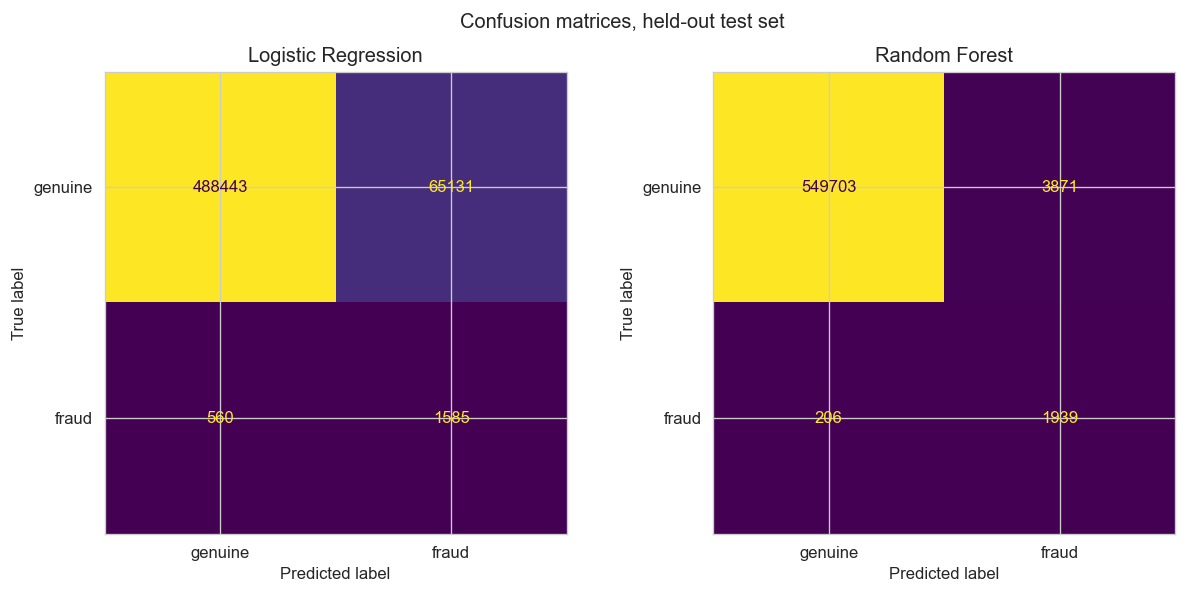

In [6]:
lr_cm = confusion_matrix(y_test, lr_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression confusion matrix (rows=actual, cols=predicted):")
print(lr_cm)
print("\nRandom Forest confusion matrix (rows=actual, cols=predicted):")
print(rf_cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(lr_cm, display_labels=['genuine', 'fraud']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(rf_cm, display_labels=['genuine', 'fraud']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')
fig.suptitle('Confusion matrices, held-out test set')
fig.savefig(f'{OUT_DIR}/confusion_matrix.png', bbox_inches='tight')

## Precision-recall curves

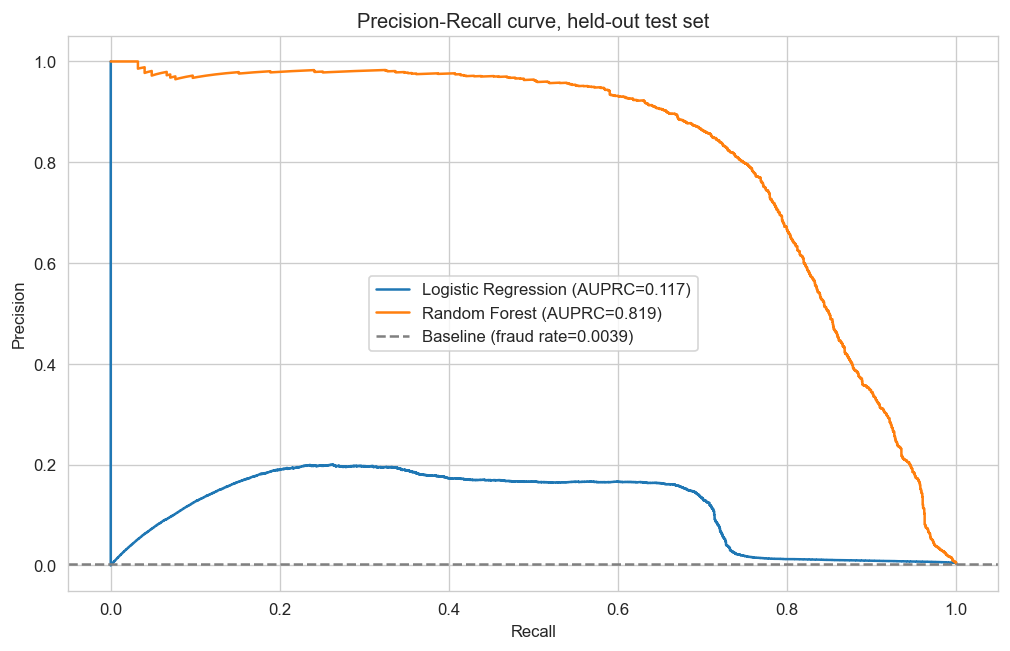

In [7]:
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_proba)
lr_auprc = average_precision_score(y_test, lr_proba)
rf_auprc = average_precision_score(y_test, rf_proba)

fig, ax = plt.subplots()
ax.plot(lr_recall, lr_precision, label=f'Logistic Regression (AUPRC={lr_auprc:.3f})')
ax.plot(rf_recall, rf_precision, label=f'Random Forest (AUPRC={rf_auprc:.3f})')
ax.axhline(y_test.mean(), color='grey', linestyle='--', label=f'Baseline (fraud rate={y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve, held-out test set')
ax.legend()
fig.savefig(f'{OUT_DIR}/pr_curve.png', bbox_inches='tight')

## Business-framed threshold: precision at 90% recall

A single 0.5-threshold number isn't the whole story for a fraud team, they can pick the
operating point. This pulls out what precision costs to catch 90% of fraud, a concrete number
for the metric justification and the Part 2 video.

In [8]:
def precision_at_recall(precision, recall, target_recall=0.90):
    # recall is monotonically decreasing along the curve, take the highest-precision point that
    # still clears the target
    idx = np.where(recall >= target_recall)[0]
    if len(idx) == 0:
        return None
    best = idx[np.argmax(precision[idx])]
    return precision[best]

target_recall = 0.90
threshold_rows = []
for name, prec, rec in [('Logistic Regression', lr_precision, lr_recall), ('Random Forest', rf_precision, rf_recall)]:
    p = precision_at_recall(prec, rec, target_recall)
    threshold_rows.append({'model': name, 'recall_target': target_recall, 'precision_at_target': p})
    print(f"{name}: at {target_recall:.0%} recall, precision is {p:.3f} "
          f"(only {p*100:.1f} out of every 100 flagged transactions would actually be fraud)")

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(f'{OUT_DIR}/threshold_summary.csv', index=False)
print("\nSaved to", f'{OUT_DIR}/threshold_summary.csv')

Logistic Regression: at 90% recall, precision is 0.009 (only 0.9 out of every 100 flagged transactions would actually be fraud)
Random Forest: at 90% recall, precision is 0.344 (only 34.4 out of every 100 flagged transactions would actually be fraud)

Saved to outputs/frauddetection/threshold_summary.csv


## Feature importance / coefficients

In [9]:
rf_importance = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
lr_coef = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=X_train.columns)
lr_coef_sorted = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index)

print("Top 10 RF features:")
print(rf_importance.head(10))
print("\nTop 10 LR coefficients (by magnitude):")
print(lr_coef_sorted.head(10))

Top 10 RF features:
amt                       0.535603
hour                      0.213307
category_shopping_net     0.026846
category_grocery_pos      0.026058
age                       0.023965
category_gas_transport    0.019421
city_pop                  0.015003
category_home             0.013458
distance_km               0.011504
category_misc_net         0.009755
dtype: float64

Top 10 LR coefficients (by magnitude):
amt                       1.686596
category_shopping_net    -0.844785
category_shopping_pos    -0.803902
category_gas_transport    0.708804
category_grocery_pos      0.387240
category_misc_net        -0.380558
hour                      0.348599
category_grocery_net      0.342219
category_entertainment   -0.288833
category_misc_pos         0.273593
dtype: float64


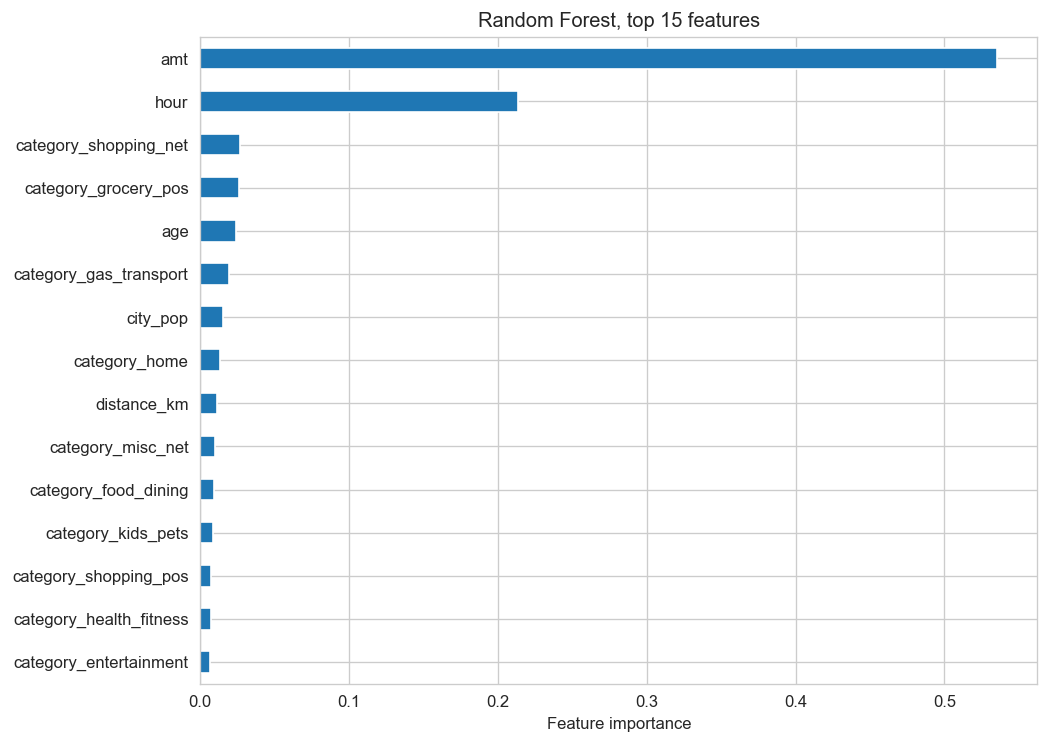

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
rf_importance.head(15)[::-1].plot(kind='barh', ax=ax)
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest, top 15 features')
fig.savefig(f'{OUT_DIR}/rf_feature_importance.png', bbox_inches='tight')

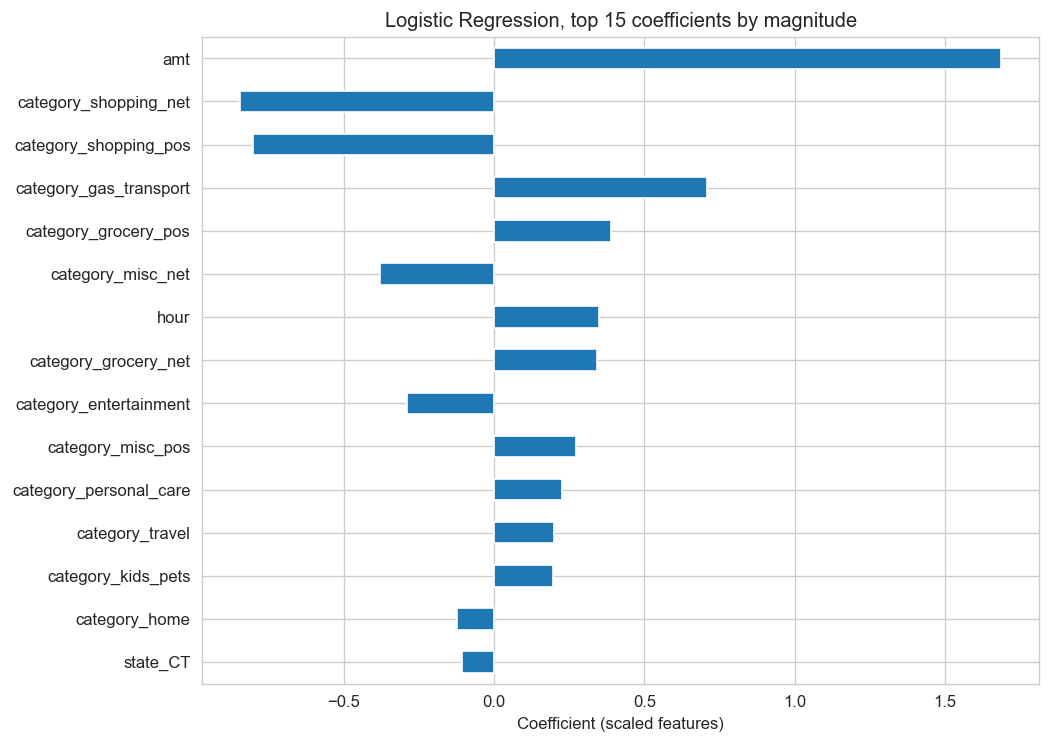

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
lr_coef_sorted.head(15)[::-1].plot(kind='barh', ax=ax)
ax.set_xlabel('Coefficient (scaled features)')
ax.set_title('Logistic Regression, top 15 coefficients by magnitude')
fig.savefig(f'{OUT_DIR}/lr_coefficients.png', bbox_inches='tight')

## Summary

In [12]:
print("--- Test set metrics ---")
print(metrics_df.to_string(index=False))
print("\nTop 5 RF features:", rf_importance.head(5).index.tolist())
print("Top 5 LR features (by |coef|):", lr_coef_sorted.head(5).index.tolist())

--- Test set metrics ---
              model  precision   recall       f1    auprc
Logistic Regression   0.023757 0.738928 0.046035 0.117077
      Random Forest   0.333735 0.903963 0.487492 0.819325

Top 5 RF features: ['amt', 'hour', 'category_shopping_net', 'category_grocery_pos', 'age']
Top 5 LR features (by |coef|): ['amt', 'category_shopping_net', 'category_shopping_pos', 'category_gas_transport', 'category_grocery_pos']
